# California Housing Market Analysis with SQL

**Author:** JaDarrien Tatum · M.S. Data Science student, Tarleton State University

An end-to-end SQL analysis of 20,640 California census districts (1990 Census housing data), written in **DuckDB SQL** and run from Python in Google Colab. The questions are the ones a housing analyst or lender would ask:

1. How clean is the data, and what are its limits?
2. How do home values differ by location (distance to the ocean)?
3. How strongly does household income drive home value?
4. Which districts are the most expensive in each market, and where does a district rank statewide?
5. Which districts look overcrowded (many people per room)?

**SQL skills shown:** `SELECT`/`WHERE`/`ORDER BY`, aggregates and `GROUP BY`, `CASE` expressions, conditional aggregation, `LEFT JOIN` anti-join checks, CTEs (`WITH`), window functions (`ROW_NUMBER`, `PERCENT_RANK`), and `quantile_cont`.

## Setup
The data is the public California housing dataset (Pace & Barry, 1997; popularized by Aurélien Géron's *Hands-On Machine Learning*). It is loaded once into an in-memory DuckDB table.

In [ ]:
import duckdb, pandas as pd, matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
con = duckdb.connect()
con.register("raw_df", pd.read_csv(URL))
con.execute("CREATE OR REPLACE TABLE housing AS SELECT * FROM raw_df")

def q(sql):
    """Run a SQL query and return the result as a pandas DataFrame."""
    return con.execute(sql).fetchdf()

q("DESCRIBE housing")

,column_name,column_type,null,key,default,extra
0,longitude,DOUBLE,YES,None,None,None
1,latitude,DOUBLE,YES,None,None,None
2,housing_median_age,DOUBLE,YES,None,None,None
3,total_rooms,DOUBLE,YES,None,None,None
4,total_bedrooms,DOUBLE,YES,None,None,None
5,population,DOUBLE,YES,None,None,None
6,households,DOUBLE,YES,None,None,None
7,median_income,DOUBLE,YES,None,None,None
8,median_house_value,DOUBLE,YES,None,None,None
9,ocean_proximity,VARCHAR,YES,None,None,None


## 1. Data quality check
Before any analysis: how many rows, how many missing values, and is any column capped?

In [ ]:
q("""
SELECT COUNT(*)                                                       AS districts,
       COUNT(*) - COUNT(total_bedrooms)                               AS missing_bedrooms,
       SUM(CASE WHEN median_house_value >= 500001 THEN 1 ELSE 0 END)  AS capped_values,
       ROUND(100.0 * SUM(CASE WHEN median_house_value >= 500001 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_capped,
       MIN(median_house_value)                                        AS min_value,
       MAX(median_house_value)                                        AS max_value
FROM housing
""")

,districts,missing_bedrooms,capped_values,pct_capped,min_value,max_value
0,20640,207,965.0,4.7,14999.0,500001.0


**Takeaway:** some districts are missing `total_bedrooms`, and home values are **top-coded at 500,001 dollars**. Averages for the most expensive markets are therefore *understated*, so medians and the share of capped districts are reported next to every average below.

## 2. Home values by location

In [ ]:
by_location = q("""
SELECT ocean_proximity,
       COUNT(*)                                        AS districts,
       ROUND(AVG(median_house_value))                  AS avg_value,
       ROUND(quantile_cont(median_house_value, 0.5))   AS median_value,
       ROUND(AVG(median_income) * 10000)               AS avg_income_usd,
       ROUND(100.0 * AVG(CASE WHEN median_house_value >= 500001 THEN 1 ELSE 0 END), 1) AS pct_capped
FROM housing
GROUP BY ocean_proximity
ORDER BY avg_value DESC
""")
by_location

,ocean_proximity,districts,avg_value,median_value,avg_income_usd,pct_capped
0,ISLAND,5,380440.0,414700.0,27444.0,0.0
1,NEAR BAY,2290,259212.0,233800.0,41729.0,8.5
2,NEAR OCEAN,2658,249434.0,229450.0,40058.0,8.0
3,<1H OCEAN,9136,240084.0,214850.0,42307.0,5.8
4,INLAND,6551,124805.0,108500.0,32090.0,0.4


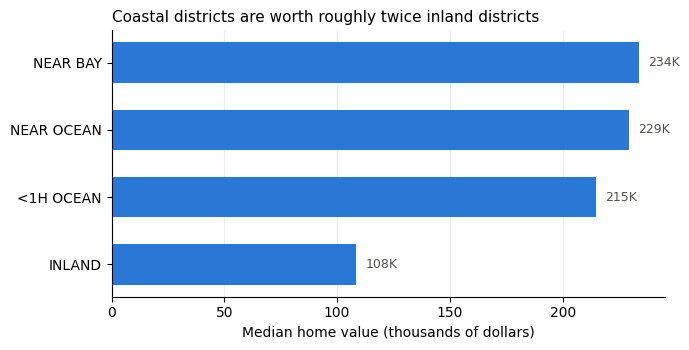

In [ ]:
d = by_location[by_location.districts >= 100]   # ISLAND has only 5 districts, too few to compare
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(d.ocean_proximity, d.median_value / 1000, color="#2a78d6", height=0.6)
for y, v in enumerate(d.median_value / 1000):
    ax.text(v + 4, y, f"{v:,.0f}K", va="center", fontsize=9, color="#52514e")
ax.invert_yaxis()
ax.set_xlabel("Median home value (thousands of dollars)")
ax.set_title("Coastal districts are worth roughly twice inland districts", loc="left", fontsize=11)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 3. Income vs. home value
`median_income` is recorded in tens of thousands of dollars. A `CASE` expression buckets districts into income bands, and conditional aggregation counts capped districts in the same pass.

In [ ]:
by_income = q("""
SELECT CASE
         WHEN median_income < 2 THEN '1. Under 20K'
         WHEN median_income < 4 THEN '2. 20K-40K'
         WHEN median_income < 6 THEN '3. 40K-60K'
         WHEN median_income < 8 THEN '4. 60K-80K'
         ELSE                        '5. 80K+'
       END                                                            AS income_band,
       COUNT(*)                                                       AS districts,
       ROUND(AVG(median_house_value))                                 AS avg_value,
       SUM(CASE WHEN median_house_value >= 500001 THEN 1 ELSE 0 END)  AS capped
FROM housing
GROUP BY income_band
ORDER BY income_band
""")
by_income

,income_band,districts,avg_value,capped
0,1. Under 20K,2439,112513.0,16.0
1,2. 20K-40K,10077,167921.0,96.0
2,3. 40K-60K,5751,244385.0,195.0
3,4. 60K-80K,1682,344452.0,217.0
4,5. 80K+,691,460371.0,441.0


In [ ]:
q("SELECT ROUND(corr(median_income, median_house_value), 3) AS income_value_correlation FROM housing")

,income_value_correlation
0,0.688


## 4. Data integrity: does every district match the lookup table?
A small lookup table groups the five location codes into *Coastal* and *Inland*. Before using it, a `LEFT JOIN` with `WHERE l.ocean_proximity IS NULL` (an anti-join) confirms that no district is left unmatched.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE location_lookup AS
SELECT * FROM (VALUES
  ('NEAR BAY',   'Coastal'),
  ('NEAR OCEAN', 'Coastal'),
  ('<1H OCEAN',  'Coastal'),
  ('ISLAND',     'Coastal'),
  ('INLAND',     'Inland')
) AS t(ocean_proximity, market)
""")

q("""
SELECT COUNT(*) AS unmatched_districts
FROM housing h
LEFT JOIN location_lookup l USING (ocean_proximity)
WHERE l.ocean_proximity IS NULL
""")

,unmatched_districts
0,0


In [ ]:
q("""
SELECT l.market,
       COUNT(*)                            AS districts,
       ROUND(AVG(h.median_house_value))    AS avg_value,
       ROUND(AVG(h.median_income) * 10000) AS avg_income_usd
FROM housing h
JOIN location_lookup l USING (ocean_proximity)
GROUP BY l.market
""")

,market,districts,avg_value,avg_income_usd
0,Coastal,14089,245007.0,41783.0
1,Inland,6551,124805.0,32090.0


## 5. Window functions: top districts per market and statewide rank

In [ ]:
q("""
WITH ranked AS (
  SELECT ocean_proximity, latitude, longitude, median_income, median_house_value,
         ROW_NUMBER() OVER (PARTITION BY ocean_proximity
                            ORDER BY median_house_value DESC, median_income DESC) AS rank_in_market
  FROM housing
)
SELECT *
FROM ranked
WHERE rank_in_market <= 3
ORDER BY ocean_proximity, rank_in_market
""")

,ocean_proximity,latitude,longitude,median_income,median_house_value,rank_in_market
0,<1H OCEAN,34.19,-118.19,15.0001,500001.0,1
1,<1H OCEAN,34.11,-118.40,15.0001,500001.0,2
2,<1H OCEAN,34.05,-118.49,15.0001,500001.0,3
3,INLAND,34.15,-118.06,15.0001,500001.0,1
4,INLAND,34.13,-118.04,15.0001,500001.0,2
5,INLAND,37.87,-121.97,13.4883,500001.0,3
6,ISLAND,33.34,-118.32,2.7361,450000.0,1
7,ISLAND,33.35,-118.32,2.1579,450000.0,2
8,ISLAND,33.34,-118.33,2.8333,414700.0,3
9,NEAR BAY,37.79,-122.50,15.0001,500001.0,1


In [ ]:
# Where does each market's income sit statewide? PERCENT_RANK gives every district a 0-1 percentile.
q("""
SELECT ocean_proximity,
       ROUND(AVG(income_pct), 2) AS avg_income_percentile
FROM (
  SELECT ocean_proximity,
         PERCENT_RANK() OVER (ORDER BY median_income) AS income_pct
  FROM housing
)
GROUP BY ocean_proximity
ORDER BY avg_income_percentile DESC
""")

,ocean_proximity,avg_income_percentile
0,<1H OCEAN,0.56
1,NEAR BAY,0.55
2,NEAR OCEAN,0.52
3,INLAND,0.39
4,ISLAND,0.30


## 6. Overcrowding screen (CTEs + a percentile threshold)
People per room is computed for every district, and districts above the statewide 99th percentile are flagged. A screen like this is how an analyst finds outliers worth a closer look, or data errors.

In [ ]:
q("""
WITH ratios AS (
  SELECT *, population * 1.0 / NULLIF(total_rooms, 0) AS people_per_room
  FROM housing
),
cutoff AS (
  SELECT quantile_cont(people_per_room, 0.99) AS p99 FROM ratios
)
SELECT r.ocean_proximity,
       COUNT(*)                          AS flagged_districts,
       ROUND(AVG(r.people_per_room), 2)  AS avg_people_per_room,
       ROUND(AVG(r.median_house_value))  AS avg_value
FROM ratios r, cutoff c
WHERE r.people_per_room > c.p99
GROUP BY r.ocean_proximity
ORDER BY flagged_districts DESC
""")

,ocean_proximity,flagged_districts,avg_people_per_room,avg_value
0,<1H OCEAN,127,1.89,167665.0
1,INLAND,38,17.32,122487.0
2,NEAR OCEAN,30,4.18,154330.0
3,NEAR BAY,12,2.71,289692.0


## 7. Map view

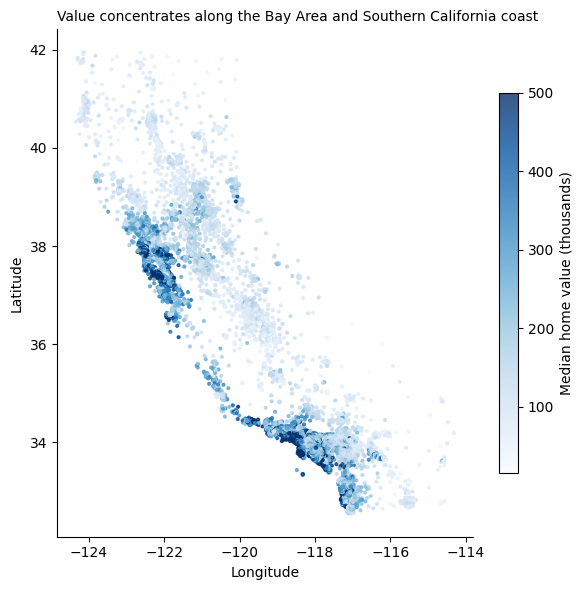

In [ ]:
df = q("SELECT longitude, latitude, median_house_value FROM housing")
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df.longitude, df.latitude, c=df.median_house_value / 1000, cmap="Blues", s=4, alpha=0.8)
cb = plt.colorbar(sc, ax=ax, shrink=0.75); cb.set_label("Median home value (thousands)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Value concentrates along the Bay Area and Southern California coast", loc="left", fontsize=10)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## Findings

- **Know the data's limits first.** 207 districts (1%) are missing bedroom counts, and 965 districts (4.7%) are top-coded at 500,001 dollars. The cap is concentrated on the coast (8.5% of NEAR BAY districts vs 0.4% of INLAND), so coastal averages are *understated*.
- **Location roughly doubles value.** The median inland district is worth 108,500 dollars versus 214,850 to 233,800 for the three coastal categories. Coastal household incomes are only about 30% higher (41.8K vs 32.1K), so most of the gap is a location premium, not an income effect.
- **Income is the strongest single driver.** Correlation with home value is 0.69. Average value climbs from 112,513 dollars in the lowest income band to 460,371 in the highest, and 64% of the highest-income districts (441 of 691) hit the cap.
- **Ranking needs a tie-breaker.** The top three districts in four of the five markets are all capped at 500,001, so `ROW_NUMBER` falls back to income to order them. The island districts are the exception: values of 414,700 to 450,000 dollars despite the lowest average income percentile (0.30).
- **The overcrowding screen surfaces data problems.** 207 districts exceed the 99th percentile of people per room. Inland flagged districts average 17.3 people per room, which is not physically plausible for households and points to group quarters (prisons, dormitories) or recording errors. These rows should be excluded or modeled separately before any price model is fit.